In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells

PDK.activate()

Objective: Finalize the full die layout with test structures for fabrication.
Steps:
1. Integrate the wvl tracker layout with input/output connections.
2. Add test structures (e.g., waveguides, and mmis)
to enable characterization of the filter.
3. Export the final .GDS file for submission and verification

In [2]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

In [3]:
main = gf.Component()
die_ref = main << die(dieW = dieW, layer_box = "FLOORPLAN")

AÑADO LAS DEFINICIONES QUE HAGO DENTRO DEL PDK. AÑADO: añado todo lo necesario a wvl_tracker. Dar importancia a lo que he definido yo que es el mmi3x3 y el wvl_tracker como circuito. Además, en cuanto a las estructuras de test, también convendría definirlas una a una. (mmi's con s_bends, espiral con los delays)

2026-05-12 15:37:57.406 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


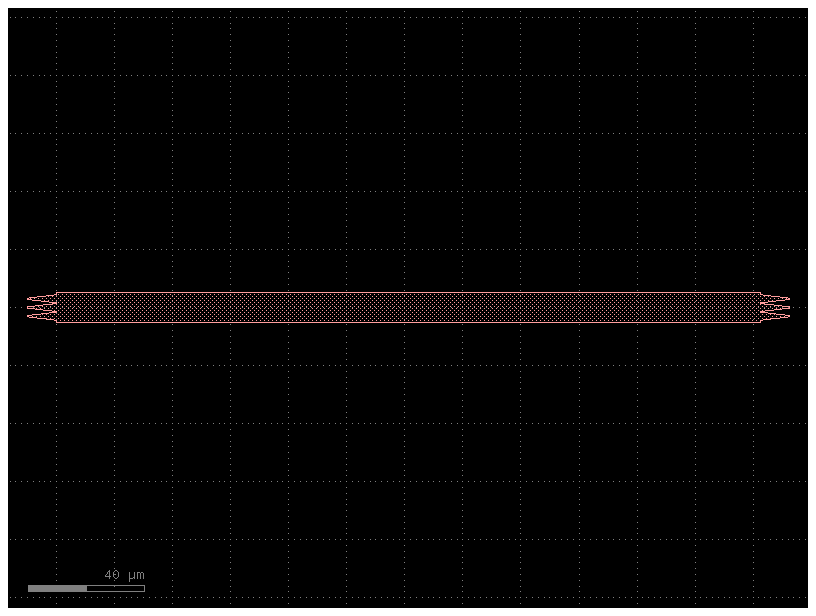

In [4]:
c = cells.mmi3x3(width= 0.45, width_taper=2.8, length_taper= 10.0, length_mmi = 242.4723, width_mmi= 10, gap_mmi = 0.2)

c.show()
c.plot()

## ESPIRAL: 

In [5]:
"""
Spirals for cutback prop.loss measurement
DoE: Assuming 1dB/cm loss: 1.5cm difference between spirals mean 1.5dB difference between
measurements.
"""
#from upvfab.sin300.cband.cells import define_spiral_length
rad = 10
N_spr = 10
dy_spr = 10
target_length = 56000  # in microns 
#target_length = 56032.624

dx_length_spiral = cells.define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])
print(spiral.info["lx_final"])
print(dx_length_spiral)

Defining spiral length for delay: 56000
Spiral length set to: 2152.431640625
Spiral length 55999.889
2382.432
2152.431640625


## CIRCUITO

2026-05-12 16:13:14.632 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/1582829281.oas'
Longitud total del dispositivo: 2977.8766 um
Longitud del brazo corto: 2432.4320000000002 um


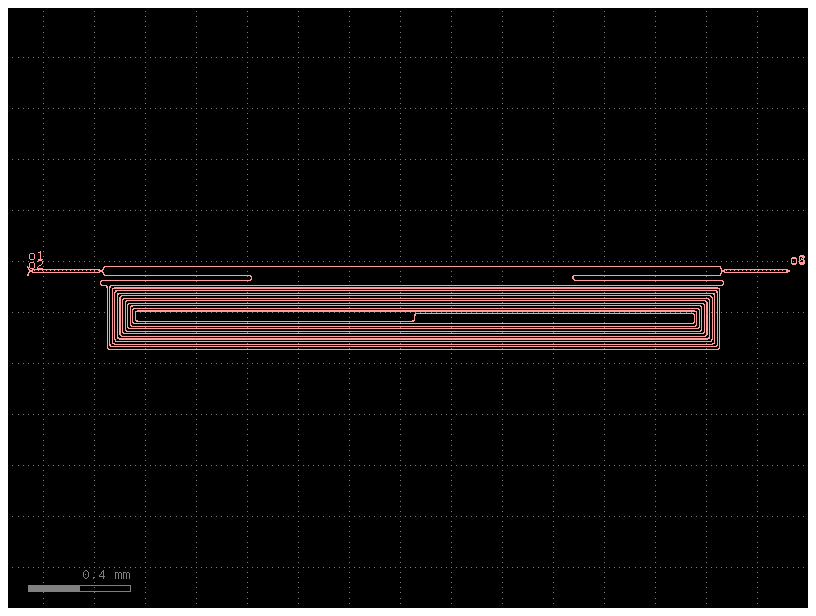

In [3]:
c = gf.Component()
circuito = c << cells.wvl_tracker()
cto_info = cells.wvl_tracker()
c.add_ports(circuito)
c.draw_ports()
c.plot()
c.show()
print(f'Longitud total del dispositivo: {cto_info.info["total_length_device"]} um')
print(f'Longitud del brazo corto: {cto_info.info["length_short_arm"]} um')
h_bends_33 = cto_info.info["h_bends_33"]

## ESTRCUTURAS TEST

1. GUÍAS
2. MMI 95:05 CON BENDS
3. MMI 33:33:33 CON S_BENDS
4. ESPIRAL CON DELAYS

2026-05-12 16:08:10.388 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/809974824.oas'


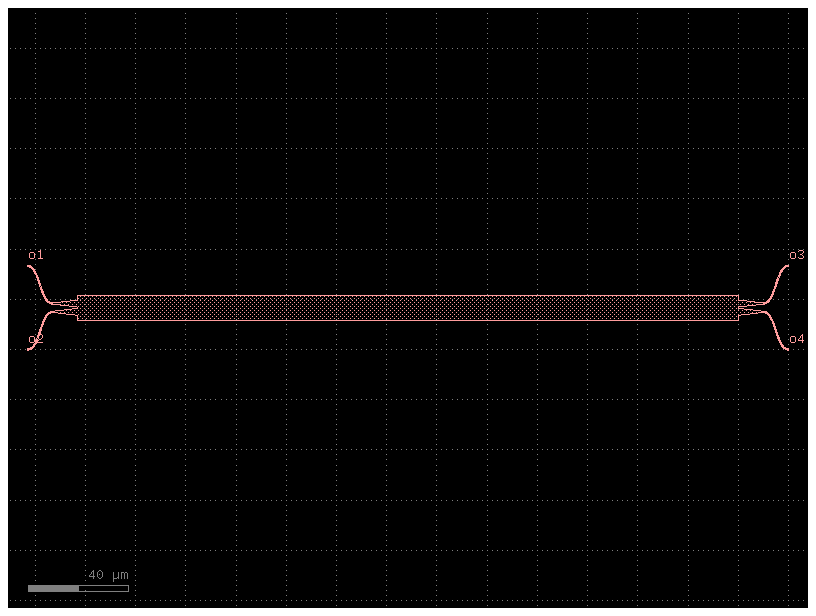

In [22]:
def mmi_2x2_test(length_mmi_2x2: float = 262.9723, taper_width_mmi_2x2: float = 2.8, gap_mmi_2x2: float = 0.5,  taper_length = 10):
    c = gf.Component()

    mmi_95 = c << cells.mmi2x2(0.45, taper_width_mmi_2x2, taper_length, length_mmi_2x2, 10, gap_mmi_2x2)
    b1 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b2 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b1.mirror_x()
    mmi_95.dmovex(b1.ports["o2"].dx - length_mmi_2x2 - taper_length).dmovey(b1.ports["o2"].dy + taper_width_mmi_2x2/2  + gap_mmi_2x2/2) 
    b2.dmovex(mmi_95.ports["o3"].dx).dmovey(mmi_95.ports["o3"].dy)

    b3 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b4 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b3.mirror_x()
    b3.mirror_y()
    b3.dmovex(mmi_95.ports["o1"].dx).dmovey(mmi_95.ports["o1"].dy)
    b4.mirror_x()
    b4.dmovex(mmi_95.ports["o2"].dx).dmovey(mmi_95.ports["o2"].dy)

    c.add_port(name = "o1", port = b4.ports["o2"], port_type = "optical")
    c.add_port(name = "o2", port = b3.ports["o2"], port_type = "optical")
    c.add_port(name = "o3", port = b2.ports["o2"], port_type = "optical")
    c.add_port(name = "o4", port = b1.ports["o1"], port_type = "optical")

    return c

c = gf.Component()
prueba = c << mmi_2x2_test()
c.add_ports(prueba)
c.draw_ports()
c.plot()
c.show()
    
    


2026-05-12 16:24:44.141 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/2917794290.oas'


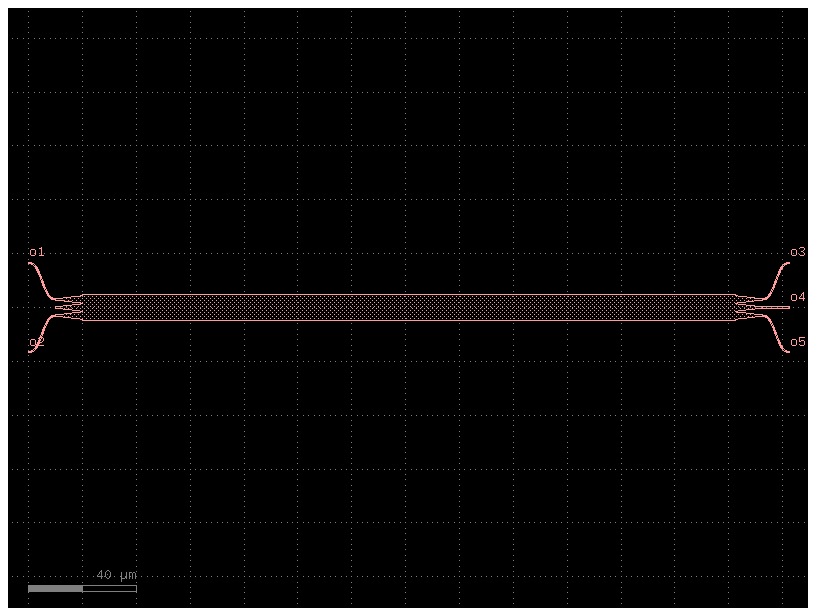

In [20]:
def mmi_3x3_test(length_mmi_3x3: float =  242.4723, taper_width_mmi_3x3: float = 2.8, gap_mmi_3x3: float = 0.2, taper_length: float = 10, altura_bends: float = 13.649999999999999 ): #altura bends heredado de cto: h_bends_33

    c = gf.Component()

    mmi_33 = c << cells.mmi3x3(width= 0.45, width_taper=taper_width_mmi_3x3, length_taper= taper_length, length_mmi = length_mmi_3x3, width_mmi= 10, gap_mmi = gap_mmi_3x3)
    b1 = c << cells.bend_s(size = [10, altura_bends], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b2 = c << cells.bend_s(size = [10, altura_bends], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b3 = c << cells.bend_s(size = [10, altura_bends], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b4 = c << cells.bend_s(size = [10, altura_bends], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    wvg = c << cells.straight(10, "strip")
    
    b1.mirror_x()
    b1.mirror_y()
    b1.dmovex(mmi_33.ports["o1"].dx).dmovey(mmi_33.ports["o1"].dy)
    b2.mirror_x()
    b2.dmovex(mmi_33.ports["o3"].dx).dmovey(mmi_33.ports["o3"].dy)
    b3.mirror_y()
    b4.dmovex(mmi_33.ports["o4"].dx).dmovey(mmi_33.ports["o4"].dy)
    b3.dmovex(mmi_33.ports["o6"].dx).dmovey(mmi_33.ports["o6"].dy)
    wvg.dmovex(mmi_33.ports["o5"].dx).dmovey(mmi_33.ports["o5"].dy)

    c.add_port(name = "o1", port = b2.ports["o2"], port_type = "optical")
    c.add_port(name = "o2", port = b1.ports["o2"], port_type = "optical")
    c.add_port(name = "o3", port = b4.ports["o2"], port_type = "optical")
    c.add_port(name = "o4", port = wvg.ports["o2"], port_type = "optical")
    c.add_port(name = "o5", port = b3.ports["o2"], port_type = "optical")
   
    

    return c

c = gf.Component()
prueba = c << mmi_3x3_test()
c.add_ports(prueba)
c.draw_ports()
c.plot()
c.show()
    

In [ ]:
b7 = c << cells.bend_s(size = [10, altura_bends], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
b8 = c << cells.bend_s(size = [10, altura_bends], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
wvg = c << cells.straight(10, "strip")